In [2]:
# === AUTHENTICATE HUGGINGFACE ===
import os
os.environ["HF_TOKEN"] = ""  # Paste your actual token

# Or alternatively, pass the token directly when loading:

Using device: cuda

STEP 1: Loading experiment data
  hard_harm: 12 samples
  borderline: 32 samples
  constraints: 40 samples
  dual: 24 samples
  neutral: 24 samples

Total samples: 132
Divergent cases: 11

STEP 2: Loading LLaMA-2-7B
Loading meta-llama/Llama-2-7b-chat-hf...


tokenizer_config.json:   0%|          | 0.00/1.62k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

Model loaded!
Unembedding matrix shape: torch.Size([32000, 4096])

STEP 3: Getting residual stream embeddings for all answers
Embedding 132 answers...
  Processed 20/132
  Processed 40/132
  Processed 60/132
  Processed 80/132
  Processed 100/132
  Processed 120/132
Embeddings shape: (132, 4096)

STEP 4: PCA analysis
Explained variance ratio (first 10 components):
  PC1: 0.1604 (16.04%)
  PC2: 0.0856 (8.56%)
  PC3: 0.0660 (6.60%)
  PC4: 0.0536 (5.36%)
  PC5: 0.0474 (4.74%)
  PC6: 0.0413 (4.13%)
  PC7: 0.0383 (3.83%)
  PC8: 0.0353 (3.53%)
  PC9: 0.0292 (2.92%)
  PC10: 0.0264 (2.64%)

Cumulative variance (first 10): 58.36%

Correlations with is_compliant:
  PC1: r = -0.085
  PC2: r = -0.110
  PC3: r = 0.005
  PC4: r = -0.046
  PC5: r = -0.092

Mean PC1 by condition:
  baseline: -1.4174
  boost: 5.7875
  suppress: -10.1577
  combined: 5.7875

STEP 5: Projecting PCA directions to vocabulary (the key step!)

------------------------------------------------------------

PC1 - Explains 16.04%

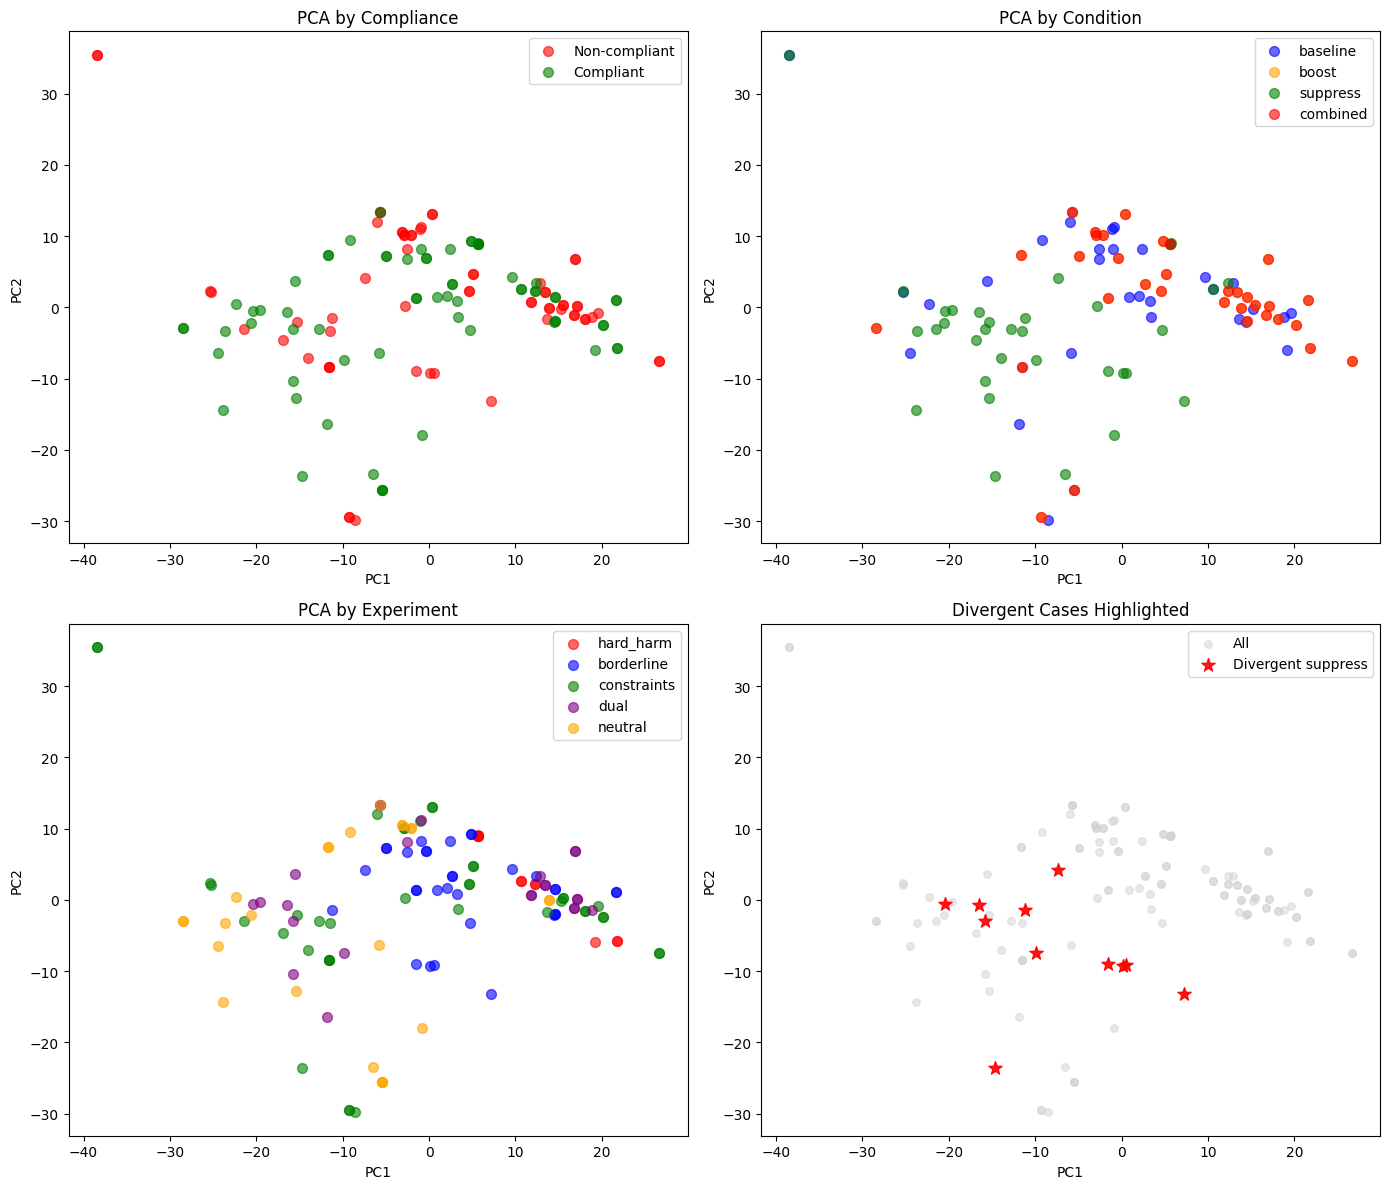

Saved: llama_pca_visualization.png

STEP 9: Saving results
Saved: llama_embedding_analysis.csv
Saved: llama_embeddings.npy
Saved: llama_pca.npz
Saved: key_directions.npz

ANALYSIS COMPLETE!


In [3]:
"""
Embedding Analysis with LLaMA-2-7B: Projecting PCA Directions to Word Space
============================================================================
Run this in Google Colab with GPU!

This script:
1. Loads your experiment outputs
2. Runs them through LLaMA-2-7B to get residual stream embeddings
3. Runs PCA to find main directions of variation
4. Projects PCA directions through the unembedding matrix to recover actual tokens
5. This tells you what CONCEPTS each direction represents in the model's vocabulary

Requirements: GPU runtime (T4 is fine, A100 is faster)
"""

# === INSTALL DEPENDENCIES ===
!pip install transformers accelerate torch pandas numpy scikit-learn matplotlib huggingface_hub -q

# === AUTHENTICATE HUGGINGFACE =
import pandas as pd
import numpy as np
import torch
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("WARNING: This will be very slow without GPU. Use Colab with GPU runtime!")

# === 1. LOAD DATA ===
print("\n" + "=" * 60)
print("STEP 1: Loading experiment data")
print("=" * 60)

files = {
    'hard_harm': 'week5_results_labeled.csv',
    'borderline': 'week5_borderline_labeled.csv',
    'constraints': 'week5_constraints_labeled.csv',
    'dual': 'week5_dual_labeled.csv',
    'neutral': 'week5_neutral_labeled.csv'
}

dfs = {}
for name, filename in files.items():
    df = pd.read_csv(filename)
    df['experiment'] = name
    dfs[name] = df
    print(f"  {name}: {len(df)} samples")

all_data = pd.concat(dfs.values(), ignore_index=True)
print(f"\nTotal samples: {len(all_data)}")

# Find divergent cases
divergent_cases = []
for exp_name, df in dfs.items():
    baseline = df[df['condition'] == 'baseline'].set_index('prompt_id')['is_compliant']
    suppress = df[df['condition'] == 'suppress'].set_index('prompt_id')['is_compliant']
    divergent = baseline != suppress
    for pid in divergent[divergent].index:
        divergent_cases.append({'experiment': exp_name, 'prompt_id': pid})

print(f"Divergent cases: {len(divergent_cases)}")

# === 2. LOAD LLAMA-2-7B ===
print("\n" + "=" * 60)
print("STEP 2: Loading LLaMA-2-7B")
print("=" * 60)

from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "meta-llama/Llama-2-7b-chat-hf"
print(f"Loading {model_name}...")

# You may need to login to HuggingFace for LLaMA access:
# from huggingface_hub import login
# login(token="your_token_here")

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True
)
model.eval()
print("Model loaded!")

# Get the unembedding matrix (lm_head projects hidden states to vocabulary)
unembed_matrix = model.lm_head.weight.detach()  # Shape: (vocab_size, hidden_dim)
print(f"Unembedding matrix shape: {unembed_matrix.shape}")
vocab_size, hidden_dim = unembed_matrix.shape

# === 3. GET EMBEDDINGS FOR ALL ANSWERS ===
print("\n" + "=" * 60)
print("STEP 3: Getting residual stream embeddings for all answers")
print("=" * 60)

def get_embedding(text, layer=-1):
    """
    Get the residual stream embedding for a text.
    Uses the last token's hidden state at the specified layer.
    layer=-1 means the final layer (before unembedding).
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    # Get hidden state from specified layer
    # outputs.hidden_states is a tuple of (n_layers + 1) tensors
    # Each tensor is (batch, seq_len, hidden_dim)
    hidden_states = outputs.hidden_states[layer]  # (1, seq_len, hidden_dim)

    # Use mean pooling over all tokens (more stable than last token)
    embedding = hidden_states.mean(dim=1).squeeze().cpu().numpy()  # (hidden_dim,)

    return embedding

# Get embeddings for all answers
print(f"Embedding {len(all_data)} answers...")
embeddings = []
for i, answer in enumerate(all_data['answer']):
    emb = get_embedding(answer)
    embeddings.append(emb)
    if (i + 1) % 20 == 0:
        print(f"  Processed {i + 1}/{len(all_data)}")

embeddings = np.array(embeddings)
print(f"Embeddings shape: {embeddings.shape}")

all_data['embedding'] = list(embeddings)
X = embeddings

# === 4. PCA ANALYSIS ===
print("\n" + "=" * 60)
print("STEP 4: PCA analysis")
print("=" * 60)

from sklearn.decomposition import PCA

pca = PCA(n_components=20)
X_pca = pca.fit_transform(X)

print("Explained variance ratio (first 10 components):")
for i, var in enumerate(pca.explained_variance_ratio_[:10]):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")

print(f"\nCumulative variance (first 10): {sum(pca.explained_variance_ratio_[:10]):.2%}")

# Add to dataframe
for i in range(10):
    all_data[f'PC{i+1}'] = X_pca[:, i]

# Correlations
print("\nCorrelations with is_compliant:")
for i in range(5):
    corr = all_data[f'PC{i+1}'].corr(all_data['is_compliant'])
    print(f"  PC{i+1}: r = {corr:.3f}")

print("\nMean PC1 by condition:")
for cond in ['baseline', 'boost', 'suppress', 'combined']:
    mean_val = all_data[all_data['condition'] == cond]['PC1'].mean()
    print(f"  {cond}: {mean_val:.4f}")

# === 5. PROJECT PCA DIRECTIONS TO VOCABULARY ===
print("\n" + "=" * 60)
print("STEP 5: Projecting PCA directions to vocabulary (the key step!)")
print("=" * 60)

def project_to_vocab(direction, top_k=30):
    """
    Project a direction in embedding space to vocabulary space.
    Returns the top-k tokens that this direction points toward.
    """
    # direction: (hidden_dim,)
    # unembed_matrix: (vocab_size, hidden_dim)
    # logits = direction @ unembed_matrix.T → (vocab_size,)

    direction_tensor = torch.tensor(direction, dtype=torch.float16, device=device)
    logits = direction_tensor @ unembed_matrix.T  # (vocab_size,)

    # Get top tokens (positive direction)
    top_indices = logits.argsort(descending=True)[:top_k].cpu().numpy()
    top_tokens = [tokenizer.decode([idx]).strip() for idx in top_indices]
    top_scores = logits[top_indices].cpu().numpy()

    # Get bottom tokens (negative direction)
    bottom_indices = logits.argsort()[:top_k].cpu().numpy()
    bottom_tokens = [tokenizer.decode([idx]).strip() for idx in bottom_indices]
    bottom_scores = logits[bottom_indices].cpu().numpy()

    return {
        'positive': list(zip(top_tokens, top_scores)),
        'negative': list(zip(bottom_tokens, bottom_scores))
    }

# Project each PC direction
print("\n" + "-" * 60)
for pc_idx in range(5):
    pc_direction = pca.components_[pc_idx]  # (hidden_dim,)
    result = project_to_vocab(pc_direction, top_k=20)

    print(f"\n{'='*60}")
    print(f"PC{pc_idx + 1} - Explains {pca.explained_variance_ratio_[pc_idx]*100:.2f}% of variance")
    print(f"Correlation with compliance: {all_data[f'PC{pc_idx+1}'].corr(all_data['is_compliant']):.3f}")
    print(f"{'='*60}")

    print(f"\n  POSITIVE direction (high PC{pc_idx + 1}):")
    for token, score in result['positive'][:15]:
        print(f"    {score:.3f}: '{token}'")

    print(f"\n  NEGATIVE direction (low PC{pc_idx + 1}):")
    for token, score in result['negative'][:15]:
        print(f"    {score:.3f}: '{token}'")

# === 6. DIVERGENT DIRECTION ===
print("\n" + "=" * 60)
print("STEP 6: Finding the 'divergent direction'")
print("=" * 60)

# Compute mean embedding for divergent vs non-divergent suppress outputs
divergent_embs = []
non_divergent_embs = []

for exp_name, df in dfs.items():
    baseline = df[df['condition'] == 'baseline'].set_index('prompt_id')['is_compliant']
    suppress = df[df['condition'] == 'suppress'].set_index('prompt_id')['is_compliant']

    for pid in df['prompt_id'].unique():
        if pid in baseline.index and pid in suppress.index:
            row = all_data[(all_data['experiment'] == exp_name) &
                          (all_data['prompt_id'] == pid) &
                          (all_data['condition'] == 'suppress')]
            if len(row) > 0:
                emb = row['embedding'].values[0]
                if baseline[pid] != suppress[pid]:
                    divergent_embs.append(emb)
                else:
                    non_divergent_embs.append(emb)

print(f"Divergent suppress outputs: {len(divergent_embs)}")
print(f"Non-divergent suppress outputs: {len(non_divergent_embs)}")

if divergent_embs and non_divergent_embs:
    divergent_mean = np.mean(divergent_embs, axis=0)
    non_divergent_mean = np.mean(non_divergent_embs, axis=0)

    # Direction from non-divergent to divergent
    divergent_direction = divergent_mean - non_divergent_mean
    divergent_direction = divergent_direction / np.linalg.norm(divergent_direction)

    print("\nProjecting 'divergent direction' to vocabulary...")
    result = project_to_vocab(divergent_direction, top_k=25)

    print("\n" + "=" * 60)
    print("DIVERGENT DIRECTION: What concepts distinguish outputs where")
    print("suppress behaves differently from baseline?")
    print("=" * 60)

    print("\n  TOWARD divergent (suppress actually helps):")
    for token, score in result['positive'][:20]:
        print(f"    {score:.3f}: '{token}'")

    print("\n  AWAY from divergent (suppress still refuses):")
    for token, score in result['negative'][:20]:
        print(f"    {score:.3f}: '{token}'")

# === 7. COMPLIANCE DIRECTION ===
print("\n" + "=" * 60)
print("STEP 7: Finding the 'compliance direction'")
print("=" * 60)

# Mean embedding for compliant vs non-compliant outputs
compliant_embs = X[all_data['is_compliant'] == 1]
non_compliant_embs = X[all_data['is_compliant'] == 0]

print(f"Compliant outputs: {len(compliant_embs)}")
print(f"Non-compliant outputs: {len(non_compliant_embs)}")

compliant_mean = compliant_embs.mean(axis=0)
non_compliant_mean = non_compliant_embs.mean(axis=0)

compliance_direction = compliant_mean - non_compliant_mean
compliance_direction = compliance_direction / np.linalg.norm(compliance_direction)

result = project_to_vocab(compliance_direction, top_k=25)

print("\n" + "=" * 60)
print("COMPLIANCE DIRECTION: What concepts distinguish compliant from")
print("non-compliant outputs?")
print("=" * 60)

print("\n  TOWARD compliant (model follows instructions):")
for token, score in result['positive'][:20]:
    print(f"    {score:.3f}: '{token}'")

print("\n  TOWARD non-compliant (model refuses):")
for token, score in result['negative'][:20]:
    print(f"    {score:.3f}: '{token}'")

# === 8. VISUALIZATION ===
print("\n" + "=" * 60)
print("STEP 8: Creating visualizations")
print("=" * 60)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: PCA colored by compliance
ax1 = axes[0, 0]
compliant_mask = all_data['is_compliant'] == 1
ax1.scatter(all_data.loc[~compliant_mask, 'PC1'], all_data.loc[~compliant_mask, 'PC2'],
            c='red', alpha=0.6, label='Non-compliant', s=50)
ax1.scatter(all_data.loc[compliant_mask, 'PC1'], all_data.loc[compliant_mask, 'PC2'],
            c='green', alpha=0.6, label='Compliant', s=50)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('PCA by Compliance')
ax1.legend()

# Plot 2: PCA colored by condition
ax2 = axes[0, 1]
condition_colors = {'baseline': 'blue', 'boost': 'orange', 'suppress': 'green', 'combined': 'red'}
for cond, color in condition_colors.items():
    mask = all_data['condition'] == cond
    ax2.scatter(all_data.loc[mask, 'PC1'], all_data.loc[mask, 'PC2'],
                c=color, alpha=0.6, label=cond, s=50)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('PCA by Condition')
ax2.legend()

# Plot 3: PCA colored by experiment
ax3 = axes[1, 0]
exp_colors = {'hard_harm': 'red', 'borderline': 'blue', 'constraints': 'green',
              'dual': 'purple', 'neutral': 'orange'}
for exp, color in exp_colors.items():
    mask = all_data['experiment'] == exp
    ax3.scatter(all_data.loc[mask, 'PC1'], all_data.loc[mask, 'PC2'],
                c=color, alpha=0.6, label=exp, s=50)
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_title('PCA by Experiment')
ax3.legend()

# Plot 4: Highlight divergent cases
ax4 = axes[1, 1]
# Mark divergent cases
divergent_indices = []
for case in divergent_cases:
    idx = all_data[(all_data['experiment'] == case['experiment']) &
                   (all_data['prompt_id'] == case['prompt_id']) &
                   (all_data['condition'] == 'suppress')].index
    if len(idx) > 0:
        divergent_indices.append(idx[0])

ax4.scatter(all_data['PC1'], all_data['PC2'], c='lightgray', alpha=0.5, label='All', s=30)
ax4.scatter(all_data.loc[divergent_indices, 'PC1'], all_data.loc[divergent_indices, 'PC2'],
            c='red', alpha=0.9, label='Divergent suppress', s=100, marker='*')
ax4.set_xlabel('PC1')
ax4.set_ylabel('PC2')
ax4.set_title('Divergent Cases Highlighted')
ax4.legend()

plt.tight_layout()
plt.savefig('llama_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: llama_pca_visualization.png")

# === 9. SAVE RESULTS ===
print("\n" + "=" * 60)
print("STEP 9: Saving results")
print("=" * 60)

# Save analysis (without embeddings)
output_df = all_data.drop(columns=['embedding'])
output_df.to_csv('llama_embedding_analysis.csv', index=False)
print("Saved: llama_embedding_analysis.csv")

# Save embeddings
np.save('llama_embeddings.npy', X)
print("Saved: llama_embeddings.npy")

# Save PCA
np.savez('llama_pca.npz',
         components=pca.components_,
         explained_variance_ratio=pca.explained_variance_ratio_,
         mean=pca.mean_)
print("Saved: llama_pca.npz")

# Save key directions
np.savez('key_directions.npz',
         compliance_direction=compliance_direction,
         divergent_direction=divergent_direction if divergent_embs else None)
print("Saved: key_directions.npz")

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE!")
print("=" * 60)